## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import random

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
augmentation = False
augmentation_weights = [0.9, 0.1]
proportion_of_augmented = 0.25
remove_outliers = True

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) PCA
7) sieć neuronowa
8) przedziały ufności / kostka wielowymiarowa i szukanie najbliższego sąsiada

## Loading the data

In [3]:
data_path = '../data/DANE.xlsx'
figures_path = '../results/visualisations/'

In [4]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)

In [6]:
inds_df = inds_df.reset_index(drop=False)

In [7]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [8]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [9]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's remove rows with missing values.

In [10]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [11]:
inDKs_df.dropna(inplace=True)

2. Let's keep only columns that we need.

In [12]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to use version with 29 numbers, just comment out the cell below.

In [13]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

In [14]:
inDKs_df = inDKs_df[inks_colnames + inds_colnames + ['Sample_id']]

### Removing ouliers

In [15]:
#plt.hist(inDKs_df['Pb_inks'], bins=100)

In [16]:
# inDKs_df['Al_inds']..nlargest50)
# inDKs_df['Al_inks']..nlargest(30)

# inDKs_df['S_inds'].nlargest(5) #165
# inDKs_df['S_inks'].nlargest(20)

# inDKs_df['Cr_inds'].nlargest(50)
# inDKs_df['Cr_inks'].nlargest(5)

# inDKs_df['Mn_inds'].nlargest(20)
# inDKs_df['Mn_inks'].nlargest(20)

# inDKs_df['Co_inds'].nlargest(20)
# inDKs_df['Co_inks'].nlargest(20) #104, 103

# inDKs_df['Cu_inds'].nlargest(50) #2381, 2384, 2382, 2375, 2383, 2376, 2378, 2380, 2373, 2379, 2372, 2374, 2371, 2377, 2370
# inDKs_df['Cu_inks'].nlargest(20) #2374, 2377, 2376, 2372, 2375, 2371, 2373, 2370, 2379, 2378, 2380, 2381, 2383, 2382, 2384

# inDKs_df['Zn_inds'].nlargest(20) #165, 896, 893, 892, 891, 897, 890, 894, 895, 899, 889, 888, 887, 886, 898, 885
# inDKs_df['Zn_inks'].nlargest(20) #104, 890, 891, 889, 895, 892, 888, 896, 894, 893, 897, 885, 887, 886, 898, 899

# inDKs_df['Pb_inds'].nlargest(20) #2128, 2129, 2127, 2126, 2125, 2124, 2123, 2122, 2120, 2121, 2119, 2118, 2117, 2115, 2116
# inDKs_df['Pb_inks'].nlargest(20) #2128, 2127, 2129, 2122, 2126, 2125, 2124, 2120, 2116, 2123, 2121, 2117, 2118, 2119, 2115

In [17]:
outliers_indices = [165, #S
                    104, 103 #Co
                    ] + \
                    list(range(2370, 2385)) + \
                    list(range(885, 900)) + \
                    list(range(2115, 2130)) #Cu, Zn, Pb

In [18]:
if remove_outliers:
    inDKs_df.drop(inDKs_df.index[outliers_indices], inplace=True)

Now we have Sample ids from 0 to 160, excluding 59, 141, 158.

### Train test split

In [19]:
if keep_sample_together:
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

In [20]:
# if augmentation:
#     X_train = torch.cat([X_train, X_aug])
#     y_train = torch.cat([y_train, y_aug])

### Data augmentation

In [21]:
if real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [22]:
if real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))
    
    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']
    
    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [23]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']
if augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[inds_colnames].values)
y_train = np.array(X_y_train[inks_colnames].values)
X_val = np.array(X_y_val[inds_colnames].values)
y_val = np.array(X_y_val[inks_colnames].values)
X_test = np.array(X_y_test[inds_colnames].values)
y_test = np.array(X_y_test[inks_colnames].values)
if augmentation:
    X_augmented = np.array(X_y_augmented[inds_colnames].values)
    y_augmented = np.array(X_y_augmented[inks_colnames].values)

### Normalization

In [24]:
if augmentation:
    X_all = np.concatenate([X_train, X_augmented])
    y_all = np.concatenate([y_train, y_augmented])
    
    X_all = (X_all - np.mean(X_all, axis=0))/np.std(X_all, axis=0)
    y_all = (y_all - np.mean(y_all, axis=0))/np.std(y_all, axis=0)
        
    X_train = X_all[:X_train.shape[0],:]
    X_augmented = X_all[X_train.shape[0]:,:]
    y_train = y_all[:y_train.shape[0],:]
    y_augmented = y_all[y_train.shape[0]:,:]
else:
    X_train = (X_train - np.mean(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.mean(y_train, axis=0))/np.std(y_train, axis=0)
    
X_val = (X_val - np.mean(X_val, axis=0))/np.std(X_val, axis=0)
y_val = (y_val - np.mean(y_val, axis=0))/np.std(y_val, axis=0)

X_test = (X_test - np.mean(X_test, axis=0))/np.std(X_test, axis=0)
y_test = (y_test - np.mean(y_test, axis=0))/np.std(y_test, axis=0)

### PCA

In [26]:
# n_components_x = 2
# n_components_y = 2

# pca_x = PCA(n_components=n_components_x)
# X_train = pca_x.fit_transform(X_train)
# X_val = pca_x.transform(X_val)
# X_test = pca_x.transform(X_test)
# if augmentation:
#     X_augmented = pca_x.transform(X_augmented)

# pca_y = PCA(n_components=n_components_y)
# y_train = pca_y.fit_transform(y_train)
# y_val = pca_y.transform(y_val)
# y_test = pca_y.transform(y_test)
# if augmentation:
#     y_augmented = pca_y.transform(y_augmented)

### PCA visualisation

In [27]:
# train_pca_df = pd.DataFrame(np.concatenate([X_train, y_train], axis=1), 
#                             columns = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
#                                     + ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)])
# train_pca_df['Sample_id'] = train_order

# val_pca_df = pd.DataFrame(np.concatenate([X_val, y_val], axis=1), 
#                             columns = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
#                                     + ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)])
# val_pca_df['Sample_id'] = val_order

# test_pca_df = pd.DataFrame(np.concatenate([X_test, y_test], axis=1), 
#                             columns = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
#                                     + ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)])
# test_pca_df['Sample_id'] = test_order

# train_val_pca_df = pd.concat([train_pca_df, val_pca_df])

In [28]:
# pc_names_x = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
# pc_names_y = ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)]

# pc_names = pc_names_x + pc_names_y

In [29]:
# mean_df = train_val_pca_df[['Sample_id']]

# for name in pc_names:
#     mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
# mean_df.drop_duplicates('Sample_id', inplace=True)
    
# mean_df.sort_values(by='Sample_id', inplace=True)
# mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_4608/2725509599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4608/2725509599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4608/2725509599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [30]:
# closest_x = []
# for i in range(train_val_pca_df.shape[0]):
#     idx_min = abs(train_val_pca_df[pc_names_x].iloc[i] - mean_df[pc_names_x]).sum(1).idxmin()
#     closest_x.append(int(mean_df.iloc[idx_min,:]['Sample_id']))
    
# closest_y = []
# for i in range(train_val_pca_df.shape[0]):
#     idx_min = abs(train_val_pca_df[pc_names_y].iloc[i] - mean_df[pc_names_y]).sum(1).idxmin()
#     closest_y.append(int(mean_df.iloc[idx_min,:]['Sample_id']))

In [31]:
# train_val_pca_df['Closest_id_X'] = closest_x
# train_val_pca_df['Closest_id_y'] = closest_y

In [32]:
# train_val_pca_df[train_val_pca_df['Closest_id_y'] == train_val_pca_df['Sample_id']]

,X_PC_1,X_PC_2,y_PC_1,y_PC_2,Sample_id,Closest_id_X,Closest_id_y
0,-0.939508,-0.025984,-0.721336,-0.190248,115,32,115
2,5.993377,-1.183670,1.486295,3.176099,153,142,153
4,-0.518423,-0.155326,-0.580629,0.460170,155,155,155
5,-0.950233,-0.037950,0.000038,-0.263081,128,128,128
12,-0.695927,0.006522,-0.366001,1.034584,148,73,148
...,...,...,...,...,...,...,...
458,3.688394,-1.299530,0.539864,2.625306,146,88,146
459,-0.160464,-0.614769,-0.667644,-0.135539,27,27,27
460,-0.404271,-0.168740,1.541499,-0.646588,91,103,91
464,3.004875,-0.695672,0.269176,2.634662,146,38,146


In [33]:
# (train_val_pca_df[train_val_pca_df['Closest_id_X'] == train_val_pca_df['Sample_id']]).shape[0] / train_val_pca_df.shape[0]

0.283148441627047

In [34]:
# (train_val_pca_df[train_val_pca_df['Closest_id_y'] == train_val_pca_df['Sample_id']]).shape[0] / train_val_pca_df.shape[0]

0.37136819862651876

In [35]:
# %matplotlib notebook

<IPython.core.display.Javascript object>


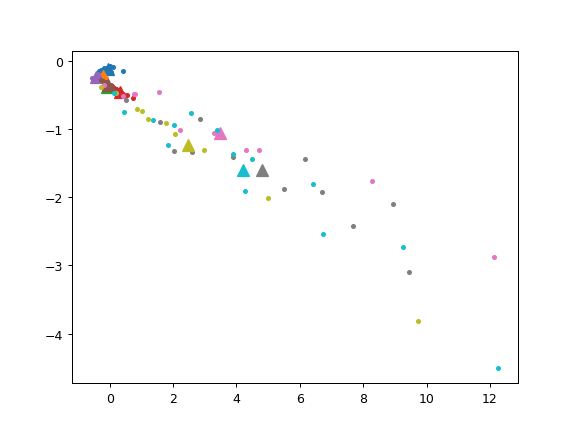

In [36]:
# up_to = 10

# # num_colors = up_to
# # cm = plt.get_cmap('gist_rainbow')
# # colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]

# # colors_vector = [list(colors_list[el]) for el in range(num_colors)]
# # cm = plt.get_cmap('gist_rainbow')
# # colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]
# # colors_vector = [list(colors_list[el]) for el in range(num_colors)]

# colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
#              '#7f7f7f', '#bcbd22', '#17becf']


# X_or_y = 'y'
# idxs_included_in_plot = list(mean_df['Sample_id'].unique())[:up_to]

# for order, idx in enumerate(idxs_included_in_plot):
#     filtered_train_val_pca_df = train_val_pca_df[train_val_pca_df['Sample_id'] == idx]
#     plt.plot(filtered_train_val_pca_df[X_or_y + '_PC_1'], 
#              filtered_train_val_pca_df[X_or_y + '_PC_2'], 
#              '.', c=colors_list[order])
    
#     filtered_mean_df = mean_df[mean_df['Sample_id'] == idx]
#     plt.plot(filtered_mean_df[X_or_y + '_PC_1'], 
#              filtered_mean_df[X_or_y + '_PC_2'],
#              c=colors_list[order], marker='^', markersize=10)

### Converting to tensors

In [25]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [26]:
if augmentation:
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
else:
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [28]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [29]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [30]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [31]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [32]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [33]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [34]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [35]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/2,1/2]).unsqueeze(1).to(device)

#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [36]:
# loss = F.l1_loss(torch.t(torch.mul(torch.t(forecast), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))) ,
#                          torch.t(torch.mul(torch.t(torch.tensor(target,dtype=torch.float).to(DEVICE)), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))),reduction='mean')
# loss.backward()
# params.append(net.parameters())
# optimiser.step()

In [37]:
EPOCHS = 3000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.5530411163965862 test 0.5394279341594579
EPOCH 2:
LOSS train 0.5375284691651662 test 0.5354121893581458
EPOCH 3:
LOSS train 0.5342238187789917 test 0.5314261066385463
EPOCH 4:
LOSS train 0.5322663982709249 test 0.5275533678410929
EPOCH 5:
LOSS train 0.5374447464942932 test 0.5237492140586869
EPOCH 6:
LOSS train 0.5271132965882619 test 0.5200390684956739
EPOCH 7:
LOSS train 0.5229374587535858 test 0.5163880552043392
EPOCH 8:
LOSS train 0.5222311913967133 test 0.5127966909154558
EPOCH 9:
LOSS train 0.5104473372300465 test 0.5092460794790887
EPOCH 10:
LOSS train 0.5146239181359609 test 0.5057733380216084
EPOCH 11:
LOSS train 0.5249021311601003 test 0.502361313137324
EPOCH 12:
LOSS train 0.5079111377398173 test 0.4990180187587497
EPOCH 13:
LOSS train 0.5011818746725718 test 0.4957050597177276
EPOCH 14:
LOSS train 0.4963499883810679 test 0.49239421975386294
EPOCH 15:
LOSS train 0.4968392233053843 test 0.4890935053490888
EPOCH 16:
LOSS train 0.4977287213007609 test 0.48

LOSS train 0.32705341577529906 test 0.316486270406641
EPOCH 130:
LOSS train 0.31136729021867116 test 0.31626721337154695
EPOCH 131:
LOSS train 0.30463453630606335 test 0.3160242903427484
EPOCH 132:
LOSS train 0.30844047566254934 test 0.3157731523847341
EPOCH 133:
LOSS train 0.3108136494954427 test 0.3155341769965515
EPOCH 134:
LOSS train 0.31505343516667683 test 0.31530161568981435
EPOCH 135:
LOSS train 0.3093308985233307 test 0.3150965991245292
EPOCH 136:
LOSS train 0.31095415651798247 test 0.3149431312480305
EPOCH 137:
LOSS train 0.30507590671380364 test 0.31468049933905967
EPOCH 138:
LOSS train 0.3291708548863729 test 0.3145197831164998
EPOCH 139:
LOSS train 0.31041796604792277 test 0.31433475730382693
EPOCH 140:
LOSS train 0.30599706967671714 test 0.3141776672662688
EPOCH 141:
LOSS train 0.31441797912120817 test 0.31409813563500527
EPOCH 142:
LOSS train 0.3198268363873164 test 0.3138718942361039
EPOCH 143:
LOSS train 0.3104265034198761 test 0.3137282103080035
EPOCH 144:
LOSS train 

LOSS train 0.2912055283784866 test 0.2954128468251995
EPOCH 256:
LOSS train 0.29001149038473767 test 0.2951118496211269
EPOCH 257:
LOSS train 0.2857019931077957 test 0.2948925805549267
EPOCH 258:
LOSS train 0.3027244687080383 test 0.2949402305623713
EPOCH 259:
LOSS train 0.29169450600941976 test 0.2947030220620869
EPOCH 260:
LOSS train 0.2855888485908508 test 0.29447885379902544
EPOCH 261:
LOSS train 0.28965266744295753 test 0.2943491080092101
EPOCH 262:
LOSS train 0.29026831487814586 test 0.2940822317567556
EPOCH 263:
LOSS train 0.2886899530887604 test 0.29396351812729604
EPOCH 264:
LOSS train 0.28401764829953513 test 0.2938159485210032
EPOCH 265:
LOSS train 0.2849674910306931 test 0.29372201961335503
EPOCH 266:
LOSS train 0.28906379838784535 test 0.293392551850669
EPOCH 267:
LOSS train 0.28997528553009033 test 0.29316646666246376
EPOCH 268:
LOSS train 0.2924967209498088 test 0.2930133496234311
EPOCH 269:
LOSS train 0.28817919790744784 test 0.29278201207848664
EPOCH 270:
LOSS train 0.

LOSS train 0.2688757369915644 test 0.27649679618105605
EPOCH 382:
LOSS train 0.26938257813453675 test 0.27636363086553944
EPOCH 383:
LOSS train 0.2636155128479004 test 0.2763099723656658
EPOCH 384:
LOSS train 0.2666301170984904 test 0.2760672363637306
EPOCH 385:
LOSS train 0.26612306336561836 test 0.27603306222455537
EPOCH 386:
LOSS train 0.26435415744781493 test 0.275885763310902
EPOCH 387:
LOSS train 0.26291366418202716 test 0.27575531018355603
EPOCH 388:
LOSS train 0.26952009499073026 test 0.27573099205828416
EPOCH 389:
LOSS train 0.26471456587314607 test 0.2756552142425114
EPOCH 390:
LOSS train 0.2714183946450551 test 0.2755333666222068
EPOCH 391:
LOSS train 0.26432447632153827 test 0.27527632746641145
EPOCH 392:
LOSS train 0.26959970196088157 test 0.2751370896880008
EPOCH 393:
LOSS train 0.26533710261185967 test 0.2751410966817651
EPOCH 394:
LOSS train 0.2615827153126399 test 0.2750038480944146
EPOCH 395:
LOSS train 0.2711815297603607 test 0.2748451451240461
EPOCH 396:
LOSS train 

LOSS train 0.2552407811085383 test 0.267530694379931
EPOCH 508:
LOSS train 0.2558190087477366 test 0.2674405309430595
EPOCH 509:
LOSS train 0.25267069737116493 test 0.2674070911026139
EPOCH 510:
LOSS train 0.2610740731159846 test 0.26730477989097184
EPOCH 511:
LOSS train 0.24952111542224883 test 0.2672468521180347
EPOCH 512:
LOSS train 0.25794335107008615 test 0.26716412514652504
EPOCH 513:
LOSS train 0.2565526048342387 test 0.26717312548325284
EPOCH 514:
LOSS train 0.25190836091836294 test 0.26719114562803054
EPOCH 515:
LOSS train 0.25352398057778675 test 0.26701617187069815
EPOCH 516:
LOSS train 0.25199814240137736 test 0.26707115609450305
EPOCH 517:
LOSS train 0.2540481001138687 test 0.26698534769096455
EPOCH 518:
LOSS train 0.25305488606293997 test 0.26686279594756757
EPOCH 519:
LOSS train 0.2643313099940618 test 0.2669132006971582
EPOCH 520:
LOSS train 0.25156074861685435 test 0.266895254893142
EPOCH 521:
LOSS train 0.254183159271876 test 0.26687778963192604
EPOCH 522:
LOSS train 

...

LOSS train 0.21673357486724854 test 0.23895816607911627
EPOCH 2473:
LOSS train 0.22095295985539753 test 0.23884967142000857
EPOCH 2474:
LOSS train 0.21335099538167318 test 0.23884453022467436
EPOCH 2475:
LOSS train 0.21903928418954213 test 0.23895107925661255
EPOCH 2476:
LOSS train 0.21856471300125122 test 0.23894478099711458
EPOCH 2477:
LOSS train 0.21728021800518035 test 0.23886682987527505
EPOCH 2478:
LOSS train 0.23243561784426373 test 0.23893033080824694
EPOCH 2479:
LOSS train 0.2322466234366099 test 0.2388726274290354
EPOCH 2480:
LOSS train 0.21652590135733288 test 0.2388973274044221
EPOCH 2481:
LOSS train 0.21539726356665292 test 0.23887228463159457
EPOCH 2482:
LOSS train 0.213044939438502 test 0.2389602075735665
EPOCH 2483:
LOSS train 0.21602781216303507 test 0.23885415937704377
EPOCH 2484:
LOSS train 0.2348326454559962 test 0.23890281645463238
EPOCH 2485:
LOSS train 0.21139662265777587 test 0.23890573716867824
EPOCH 2486:
LOSS train 0.21425012350082398 test 0.23885447105180613

LOSS train 0.22227680186430612 test 0.2381880851776854
EPOCH 2595:
LOSS train 0.21214829683303832 test 0.23829830133352226
EPOCH 2596:
LOSS train 0.21484559973080952 test 0.23810042550527974
EPOCH 2597:
LOSS train 0.2218906948963801 test 0.23817076822467745
EPOCH 2598:
LOSS train 0.22514238953590393 test 0.23820797203871016
EPOCH 2599:
LOSS train 0.21270926892757416 test 0.23821521854570396
EPOCH 2600:
LOSS train 0.2146363576253255 test 0.2381608321484697
EPOCH 2601:
LOSS train 0.21704765260219575 test 0.23820584644229478
EPOCH 2602:
LOSS train 0.2173159271478653 test 0.23812155627924556
EPOCH 2603:
LOSS train 0.21368859112262725 test 0.2381704874800416
EPOCH 2604:
LOSS train 0.21539447704950967 test 0.23816004709855412
EPOCH 2605:
LOSS train 0.2147233823935191 test 0.23808457665066804
EPOCH 2606:
LOSS train 0.21423901220162708 test 0.23809118208550073
EPOCH 2607:
LOSS train 0.21689500411351523 test 0.2381631693280133
EPOCH 2608:
LOSS train 0.21732757687568666 test 0.23801381994856183


LOSS train 0.21131469706694286 test 0.2373991244775145
EPOCH 2717:
LOSS train 0.21601331035296123 test 0.23741746297349783
EPOCH 2718:
LOSS train 0.21369532942771913 test 0.2374144908009325
EPOCH 2719:
LOSS train 0.22374952832857767 test 0.23746682572638309
EPOCH 2720:
LOSS train 0.21422917942206066 test 0.23745425504864143
EPOCH 2721:
LOSS train 0.21613245010375975 test 0.237450034031448
EPOCH 2722:
LOSS train 0.21446697811285656 test 0.23733080732970172
EPOCH 2723:
LOSS train 0.2223250369230906 test 0.2373582132569345
EPOCH 2724:
LOSS train 0.2150689442952474 test 0.23745487202037488
EPOCH 2725:
LOSS train 0.21928976476192474 test 0.23746579198190307
EPOCH 2726:
LOSS train 0.2164408564567566 test 0.23734936455288266
EPOCH 2727:
LOSS train 0.21639430622259775 test 0.2373765376376829
EPOCH 2728:
LOSS train 0.23017377456029256 test 0.23737668788712865
EPOCH 2729:
LOSS train 0.2101367597778638 test 0.23745074781750325
EPOCH 2730:
LOSS train 0.21697491109371186 test 0.23738645559436158
EP

LOSS train 0.21325094600518543 test 0.2367728307473823
EPOCH 2839:
LOSS train 0.21451963086922962 test 0.2367531690424316
EPOCH 2840:
LOSS train 0.21285258928934733 test 0.23680253129232406
EPOCH 2841:
LOSS train 0.21467207471529642 test 0.23679043820622978
EPOCH 2842:
LOSS train 0.21051479279994964 test 0.23675256448047322
EPOCH 2843:
LOSS train 0.2123983214298884 test 0.23670580680973294
EPOCH 2844:
LOSS train 0.21785573065280914 test 0.23681383324543384
EPOCH 2845:
LOSS train 0.2146103113889694 test 0.23671820142428207
EPOCH 2846:
LOSS train 0.21461871564388274 test 0.23666589089398143
EPOCH 2847:
LOSS train 0.2156189521153768 test 0.23671187066673477
EPOCH 2848:
LOSS train 0.21632236738999686 test 0.23673010018225837
EPOCH 2849:
LOSS train 0.21817357043425242 test 0.23665177979298282
EPOCH 2850:
LOSS train 0.21426908075809478 test 0.23664245335188722
EPOCH 2851:
LOSS train 0.2112705409526825 test 0.23665404425077297
EPOCH 2852:
LOSS train 0.21962139507134756 test 0.2366894046119748

LOSS train 0.21207817097504933 test 0.23626987780306788
EPOCH 2962:
LOSS train 0.2109129269917806 test 0.23616712827644143
EPOCH 2963:
LOSS train 0.21562572022279103 test 0.23623674566452765
EPOCH 2964:
LOSS train 0.21414933999379476 test 0.2362639092042539
EPOCH 2965:
LOSS train 0.21074491838614146 test 0.23619458832255397
EPOCH 2966:
LOSS train 0.2094216654698054 test 0.23625127316102826
EPOCH 2967:
LOSS train 0.2191537658373515 test 0.2362708513102325
EPOCH 2968:
LOSS train 0.21819521884123486 test 0.23624607567765793
EPOCH 2969:
LOSS train 0.21593262950579326 test 0.23612561992876516
EPOCH 2970:
LOSS train 0.2100565989812215 test 0.23621849326676206
EPOCH 2971:
LOSS train 0.21849009891351065 test 0.23618003145206076
EPOCH 2972:
LOSS train 0.22163484791914623 test 0.2360803841059155
EPOCH 2973:
LOSS train 0.22014030118783315 test 0.23621796467243242
EPOCH 2974:
LOSS train 0.21461657186349234 test 0.23631580783455056
EPOCH 2975:
LOSS train 0.21437102059523264 test 0.23630769053701986

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

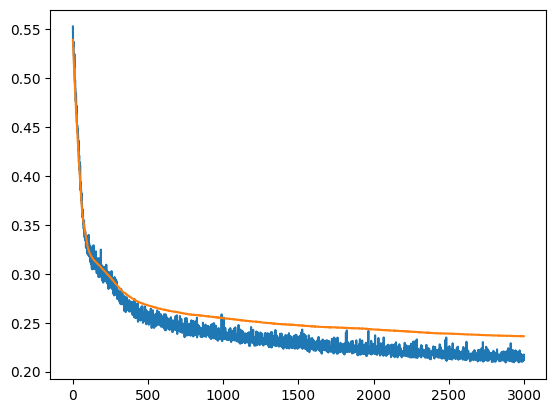

In [38]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

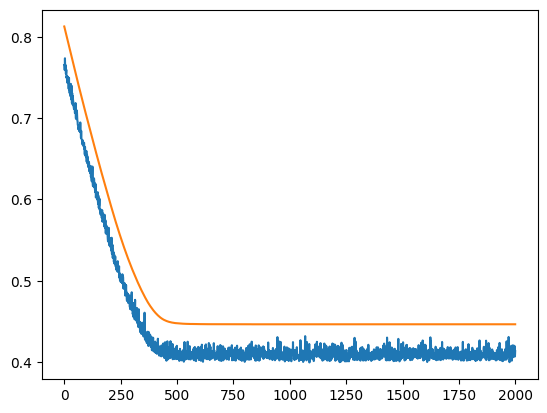

In [37]:
#No augmentation
#No keeping one sample together
#4 layers each 2 neurons, custom loss, equal weights
#PCA
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

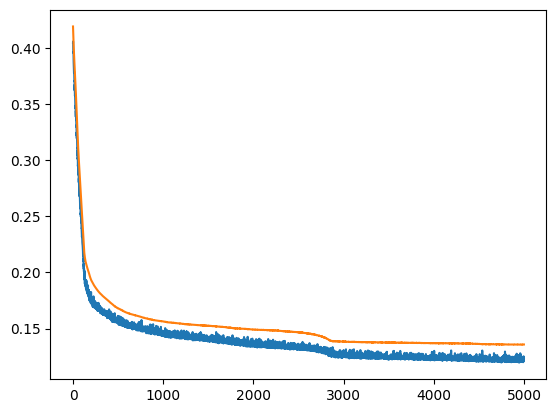

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

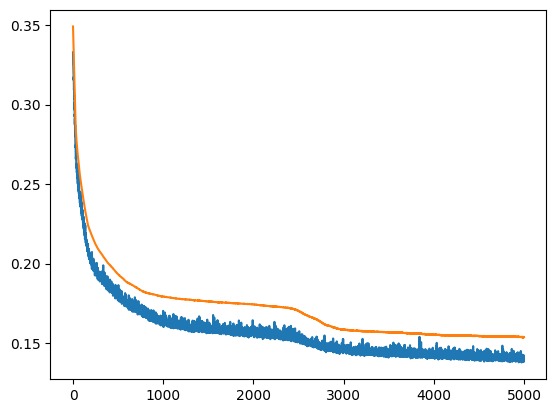

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights 1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

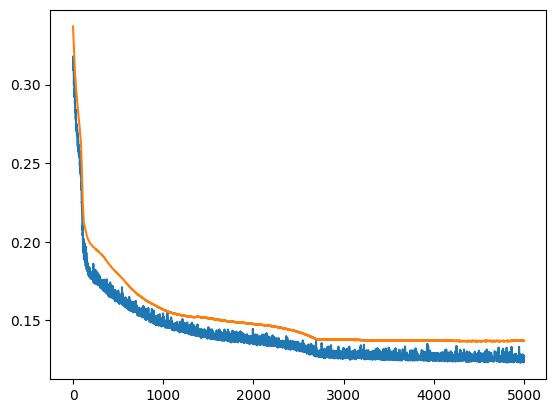

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

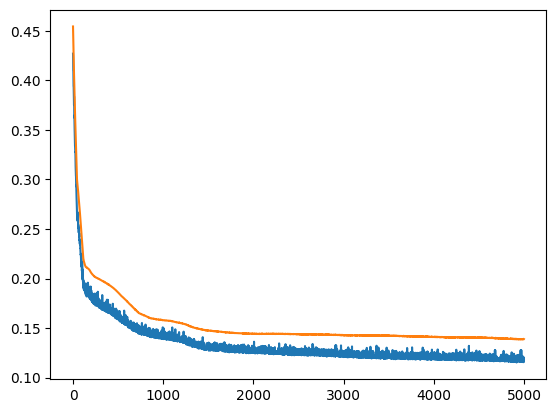

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

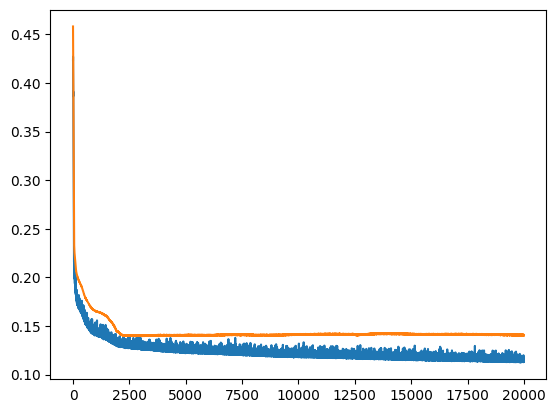

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

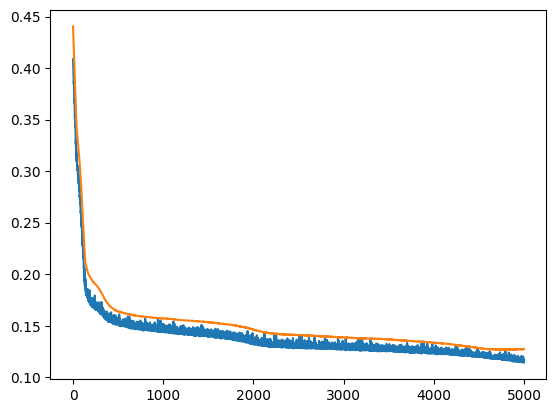

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [39]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [40]:
lab

tensor([[-0.3007, -0.3026, -0.1992,  ..., -0.1274, -0.4500, -0.3626],
        [-0.2107, -0.2478, -0.1986,  ...,  0.4935,  2.4401,  0.0389],
        [-0.1956, -0.1391, -0.1966,  ..., -0.2820, -0.2158,  1.8709],
        ...,
        [-0.1800, -0.0842, -0.1993,  ..., -0.2479, -0.4380,  0.9871],
        [-0.2483, -0.2214, -0.1982,  ..., -0.2429, -0.3911, -0.4020],
        [-0.2653, -0.1465, -0.1979,  ..., -0.2817, -0.3771, -0.3439]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [41]:
out

tensor([[-0.2445, -0.2654, -0.1529,  ..., -0.1075, -0.1669, -0.3784],
        [-0.1641, -0.1221, -0.1411,  ..., -0.1893,  0.5685, -0.0172],
        [-0.1704, -0.1832, -0.1492,  ..., -0.2885, -0.3445,  0.7242],
        ...,
        [-0.2429,  0.4224, -0.1353,  ..., -0.1752, -0.2946,  1.7224],
        [-0.2548, -0.2974, -0.1546,  ..., -0.2600, -0.4561, -0.3900],
        [-0.2487, -0.2966, -0.1537,  ..., -0.2854, -0.4403, -0.3437]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [42]:
res

tensor([[5.6184e-02, 3.7206e-02, 4.6316e-02,  ..., 1.9933e-02, 2.8314e-01,
         1.5826e-02],
        [4.6620e-02, 1.2566e-01, 5.7476e-02,  ..., 6.8281e-01, 1.8716e+00,
         5.6089e-02],
        [2.5204e-02, 4.4103e-02, 4.7306e-02,  ..., 6.5031e-03, 1.2873e-01,
         1.1467e+00],
        ...,
        [6.2840e-02, 5.0657e-01, 6.4013e-02,  ..., 7.2760e-02, 1.4332e-01,
         7.3530e-01],
        [6.5741e-03, 7.6012e-02, 4.3672e-02,  ..., 1.7099e-02, 6.5055e-02,
         1.2037e-02],
        [1.6609e-02, 1.5008e-01, 4.4212e-02,  ..., 3.6722e-03, 6.3180e-02,
         2.8062e-04]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [43]:
torch.mean(res, axis=0) 

tensor([0.2055, 0.2065, 0.1363, 0.3747, 0.2949, 0.2405, 0.2783, 0.2436],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [44]:
torch.mean(res, axis=0)

tensor([0.2055, 0.2065, 0.1363, 0.3747, 0.2949, 0.2405, 0.2783, 0.2436],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [54]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

SyntaxError: invalid syntax (4073561584.py, line 1)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [45]:
torch.mean(res)

tensor(0.2475, device='cuda:0', grad_fn=<MeanBackward0>)

In [46]:
torch.mean(res)

tensor(0.2475, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [42]:
dim_nr = 5
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [43]:
#torch.max(out, axis=0)

(-0.1, 0.1)

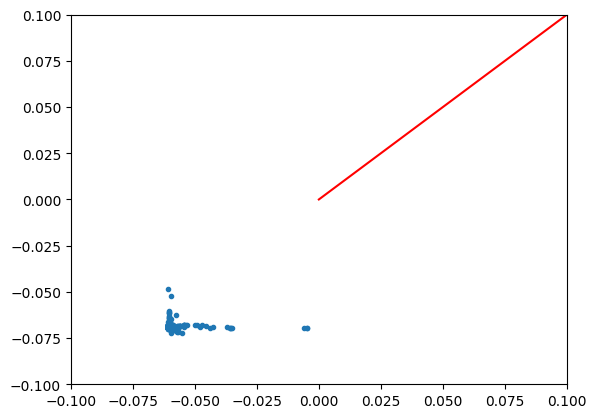

In [44]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [0,20],[0,20], 'red' )
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

In [45]:
torch.mean(res, 0)

tensor([0.1679, 0.1206, 0.1253, 0.2893, 0.3142, 0.0687, 0.1075, 0.0544],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [46]:
mean_loss

0.15598308939224506

## Quality of prediction: tSNE + closest points

In [47]:
model.eval()
outputs = model(X_test)

In [49]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [51]:
outputs_np = outputs.cpu().detach().numpy()

In [52]:
y_train_val_normalized = np.concatenate([y_train.cpu(), y_val.cpu()])

In [55]:
from sklearn.manifold import TSNE

In [110]:
n_components = 2
tsne = TSNE(n_components=n_components, verbose=1, perplexity=40, n_iter=300)
outputs_tsne = tsne.fit_transform(outputs_np)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 474 samples in 0.001s...
[t-SNE] Computed neighbors for 474 samples in 0.008s...
[t-SNE] Computed conditional probabilities for sample 474 / 474
[t-SNE] Mean sigma: 0.100860
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.601814
[t-SNE] KL divergence after 300 iterations: 0.325116


In [111]:
outputs_tsne_df = pd.DataFrame(outputs_tsne,
                          columns=['dim_' + str(numb) for numb in range(1, n_components+1)])
outputs_tsne_df.insert(0, 'Sample_id', test_order)
outputs_tsne_df.reset_index(drop=True, inplace=True)

In [112]:
outputs_tsne_df

,Sample_id,dim_1,dim_2
0,39,0.634763,-3.439103
1,34,8.643044,-2.882118
2,46,6.156131,10.144841
3,37,12.335881,4.802128
4,145,8.543888,-5.538614
...,...,...,...
469,108,-5.544848,3.184676
470,3,0.674478,-7.408216
471,31,7.812405,1.196779
472,149,-8.860065,-5.731217


In [113]:
len(colors_list)

160

In [114]:
num_colors = outputs_tsne_df['Sample_id'].max() + 1
cm = plt.get_cmap('gist_rainbow')
colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]

colors_vector = [list(colors_list[el]) for el in outputs_tsne_df['Sample_id']]
colors_vector_output = [list(colors_list[el]) for el in outputs_tsne_df['Sample_id']]

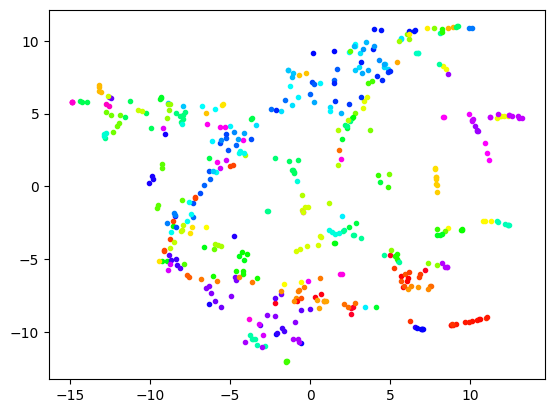

In [115]:
for i in range(outputs_tsne_df.shape[0]):
    plt.plot(outputs_tsne_df['dim_1'][i], outputs_tsne_df['dim_2'][i], '.',
             c=colors_vector[i])

In [72]:
import matplotlib.colors as mcolors

In [75]:
# num_colors = len(outputs_tsne_df['Sample_id'].unique())
# cm = plt.get_cmap('gist_rainbow')
# colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]

# colors_vector = [list(colors_list[el][0:3]) for el in outputs_tsne_df['Sample_id']]
# colors_vector_output = [list(colors_list[el][0:3]) for el in outputs_pca_df['Sample_id']]

IndexError: list index out of range

In [66]:
# train_val_pca_df = pd.DataFrame(y_train_val_normalized_pca, 
#                                 columns=['PC' + str(numb) for numb in range(1, n_components+1)])
# sample_ids = (pd.concat([train_order, val_order])).reset_index(drop=True)
# train_val_pca_df['Sample_id'] = sample_ids

# mean_df = train_val_pca_df[['Sample_id']]

# for name in ['PC' + str(numb) for numb in range(1, n_components+1)]:
#     mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
#     mean_df.drop_duplicates('Sample_id', inplace=True)
    
# mean_df.sort_values(by='Sample_id', inplace=True)
# mean_df.reset_index(drop=True, inplace=True)

In [164]:
# closest = []
# for i in range(outputs_pca_df.shape[0]):
#     closest.append((abs(outputs_pca_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [67]:
# len(closest)

In [68]:
# outputs_pca_df['Closest'] = closest

In [69]:
# outputs_pca_df[outputs_df['Sample_id'] == outputs_pca_df['Closest']].shape[0]

In [70]:
# mean_df

In [71]:
# train_val_pca_df

In [138]:
import matplotlib.colors as mcolors

In [168]:
num_colors = len(train_val_pca_df['Sample_id'].unique())
cm = plt.get_cmap('gist_rainbow')
colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]

colors_vector = [list(colors_list[el][0:3]) for el in train_val_pca_df['Sample_id']]
colors_vector_output = [list(colors_list[el][0:3]) for el in outputs_pca_df['Sample_id']]

ValueError: [[0.0, 1.0, 0.9909340080118073], [0.04239533651298355, 1.0, 0.0], [1.0, 0.7705352411234765, 0.0], [0.19077901430842603, 1.0, 0.0], [0.0, 1.0, 0.2108370229812356], [0.0, 1.0, 0.527092557453089], [0.38155802861685206, 1.0, 0.0], [0.8479067302596713, 1.0, 0.0], [0.6995230524642289, 1.0, 0.0], [0.0, 0.13533674339300916, 1.0], [0.0, 1.0, 0.04216740459624712], [0.31223358908780924, 0.0, 1.0], [1.0, 0.7281399046104929, 0.0], [0.0, 0.5402813299232734, 1.0], [0.0, 0.4763427109974422, 1.0], [1.0, 0.8977212506624273, 0.0], [0.3179650238473768, 1.0, 0.0], [1.0, 0.0, 0.013594771241830061], [0.0, 0.796035805626598, 1.0], [0.35485933503836337, 0.0, 1.0], [1.0, 0.09220985691573928, 0.0], [0.0, 0.9452259164535375, 1.0], [0.0, 0.7107843137254899, 1.0], [0.0, 0.9026001705029834, 1.0], [0.3179650238473768, 1.0, 0.0], [1.0, 0.5585585585585586, 0.0], [1.0, 0.0, 0.07633986928104575], [0.0, 1.0, 0.46384145055871834], [0.6571277159512453, 1.0, 0.0], [1.0, 0.5373608903020667, 0.0], [0.0, 0.902600170

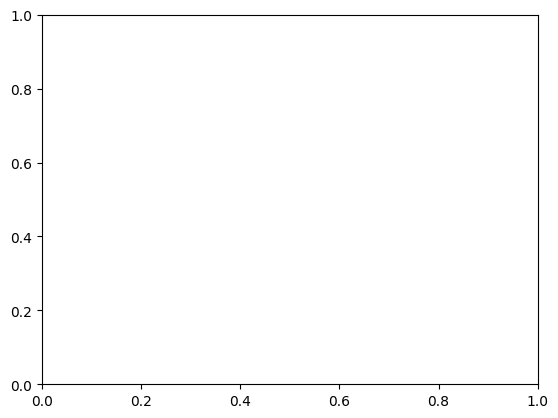

In [160]:
plt.plot(train_val_pca_df['PC1'], train_val_pca_df['PC2'], '.', c=colors_vector)

In [176]:
%matplotlib notebook

<IPython.core.display.Javascript object>


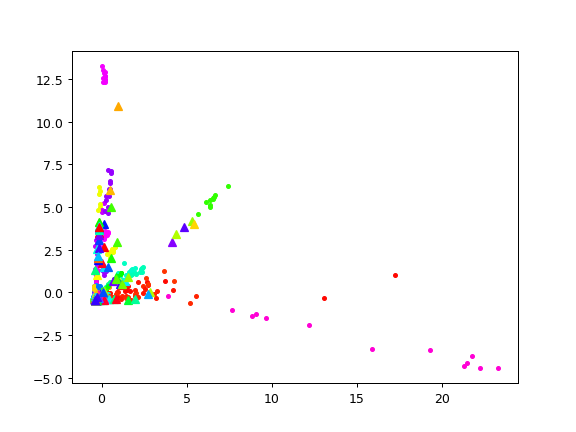

/tmp/ipykernel_15170/3367273864.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(outputs_pca_df['PC1'][i], outputs_pca_df['PC2'][i], '.',


In [178]:
for i in range(train_val_pca_df.shape[0]):
    plt.plot(train_val_pca_df['PC1'][i], train_val_pca_df['PC2'][i], '.', c=colors_vector[i])
    
for i in range(outputs_pca_df.shape[0]):
    plt.plot(outputs_pca_df['PC1'][i], outputs_pca_df['PC2'][i], '.',
             c=colors_vector[i], marker='^')

## Interpretability

...